In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

C:\Users\ritik\AppData\Local\Temp\ipykernel_10060\553251235.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])


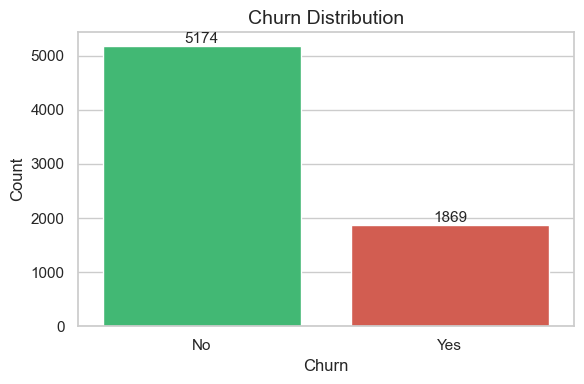

In [4]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Churn Distribution', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

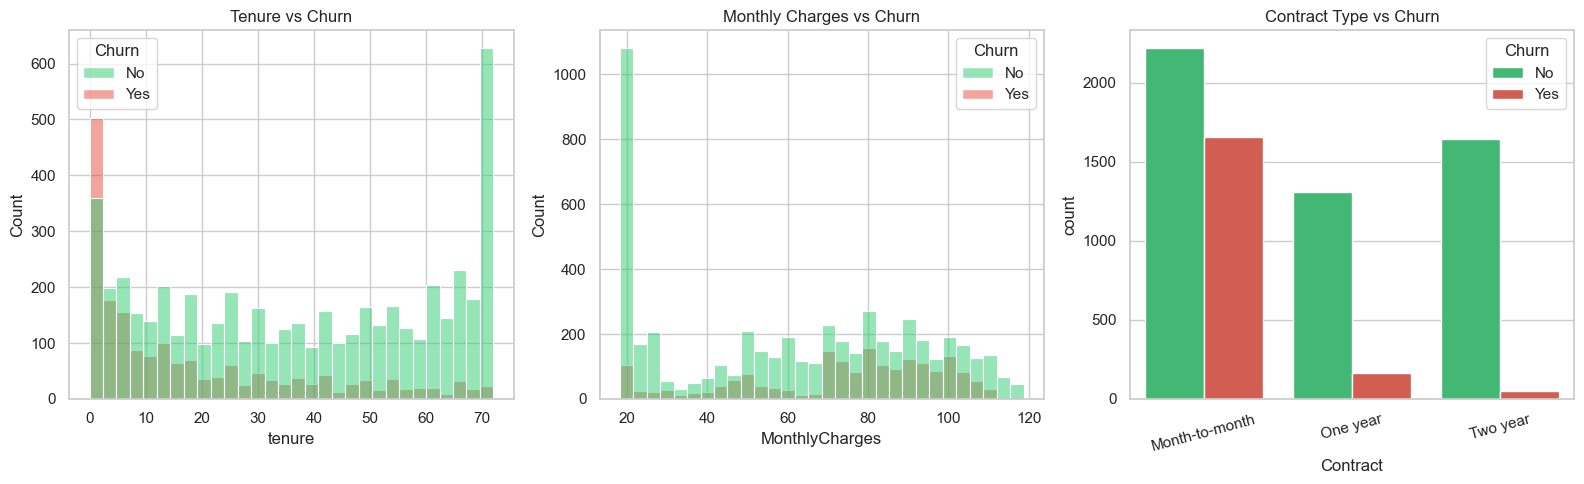

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tenure
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Tenure vs Churn')

# Monthly Charges
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30,
             palette=['#2ecc71','#e74c3c'], ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')

# Contract Type
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#2ecc71','#e74c3c'], ax=axes[2])
axes[2].set_title('Contract Type vs Churn')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [6]:
df.shape

(7043, 21)

##  Fix TotalCharges Column

In [7]:
# TotalCharges is stored as string - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values got introduced
print("NaN in TotalCharges:", df['TotalCharges'].isnull().sum())

# Fix - assign back explicitly
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Fixed! NaN values remaining:", df['TotalCharges'].isnull().sum())

NaN in TotalCharges: 11
Fixed! NaN values remaining: 0


## Drop Unnecessary Column

In [8]:
# customerID is just an identifier, not useful for prediction
df.drop(columns=['customerID'], inplace=True)
print("Dropped customerID. New shape:", df.shape)

Dropped customerID. New shape: (7043, 20)


## Encode Target Variable


In [9]:
# Convert Churn: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn value counts after encoding:")
print(df['Churn'].value_counts())

Churn value counts after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Encode All Categorical Columns

In [10]:
# Binary columns - map directly
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'Male': 1, 'Female': 0,
                           'No phone service': 0})

# Multi-class columns - One Hot Encode
multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())

Shape after encoding: (7043, 30)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## Training all 3 Model

In [11]:
from sklearn.model_selection import train_test_split

# Split data into features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (5634, 29) (5634,)
Test set shape: (1409, 29) (1409,)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Verify variables exist before training
try:
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)
    print("✅ All variables ready!")
except NameError as e:
    print(f"❌ Missing variable: {e}")
    print("Please re-run cells 1 → 10 first!")

# Calculate scale_pos_weight for XGBoost (handles imbalance)
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

# Define all 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale, 
                              use_label_encoder=False,
                              eval_metric='logloss',
                              random_state=42)
}

# Train all 3
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"✅ {name} trained!")

X_train shape: (5634, 29)
y_train shape: (5634,)
✅ All variables ready!
scale_pos_weight: 2.77


C:\Users\ritik\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


C:\Users\ritik\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [19:51:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## Evaluate Model

In [13]:
print("="*60)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("="*60)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'accuracy': acc, 'auc': auc, 
                     'pred': y_pred, 'prob': y_prob}
    
    print(f"{name:<25} {acc*100:>9.2f}% {auc:>10.4f}")

print("="*60)

Model                       Accuracy    ROC-AUC
Logistic Regression           82.11%     0.8625
Random Forest                 79.70%     0.8375
XGBoost                       77.15%     0.8371


## Detailed XGBoost Report

In [14]:
xgb_pred = results['XGBoost']['pred']

print("XGBoost Classification Report:")
print("="*50)
print(classification_report(y_test, xgb_pred, 
      target_names=['No Churn', 'Churn']))

XGBoost Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1036
       Churn       0.56      0.69      0.61       373

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409



## Confusion Matrix

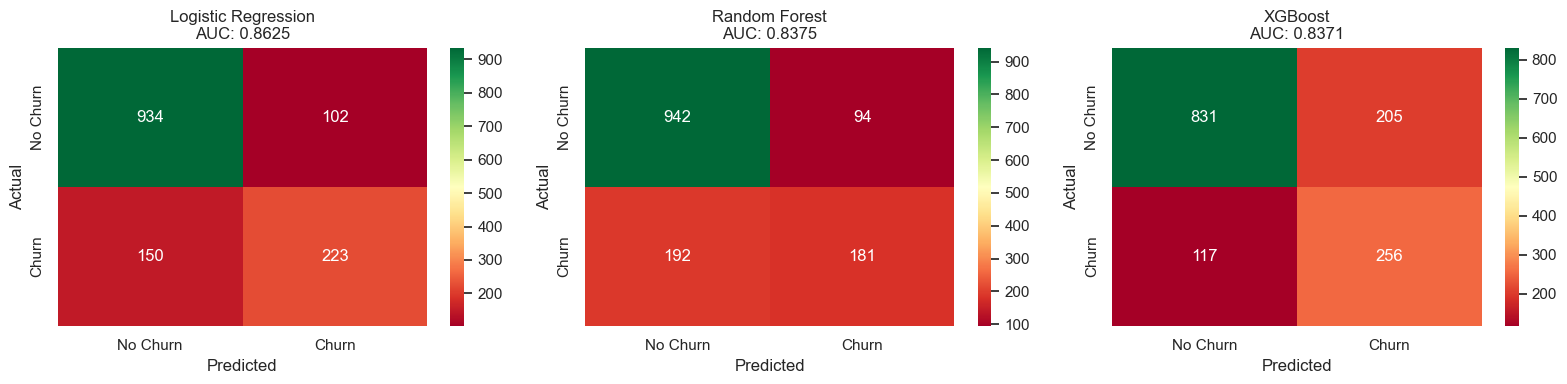

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'], ax=ax)
    ax.set_title(f'{name}\nAUC: {result["auc"]:.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Save Best Model

In [16]:
import pickle
import json

# Save Logistic Regression as final model
best_model = models['Logistic Regression']

with open('../model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature column names
with open('../model_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f)

print("✅ Best Model (Logistic Regression) saved!")
print("✅ Feature columns saved!")

✅ Best Model (Logistic Regression) saved!
✅ Feature columns saved!


In [ ]:
#pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##  Setup SHAP

In [18]:
import shap

# Initialize SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(best_model, X_train.values.astype(float))
shap_values = explainer.shap_values(X_test.values.astype(float))

print("✅ SHAP explainer ready!")
print("SHAP values shape:", shap_values.shape)

✅ SHAP explainer ready!
SHAP values shape: (1409, 29)


##  Global Feature Importance (Summary Plot)

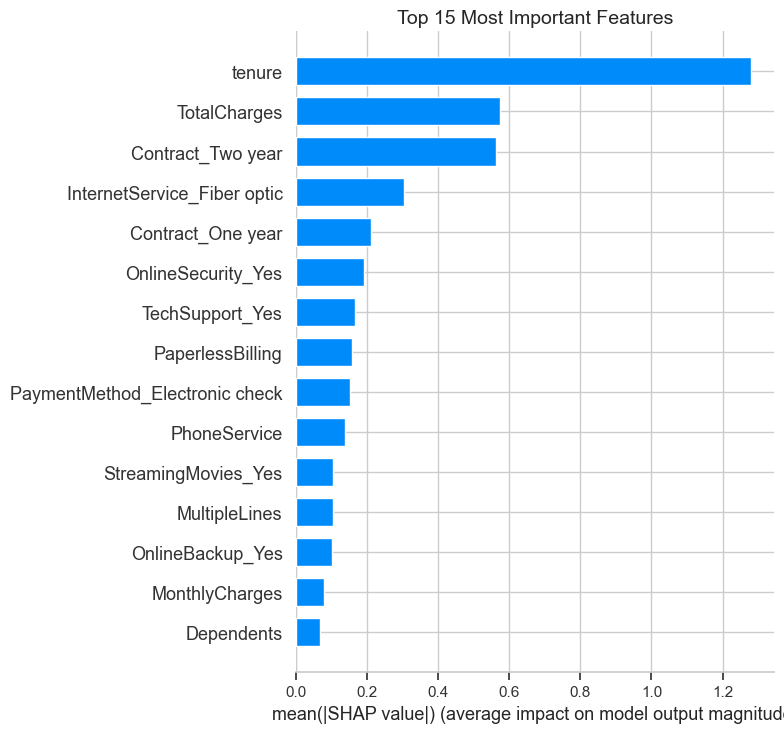

✅ Summary plot saved!


In [19]:
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title("Top 15 Most Important Features", fontsize=14)
plt.tight_layout()
plt.savefig('../shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary plot saved!")

## Detailed Dot Summary Plot

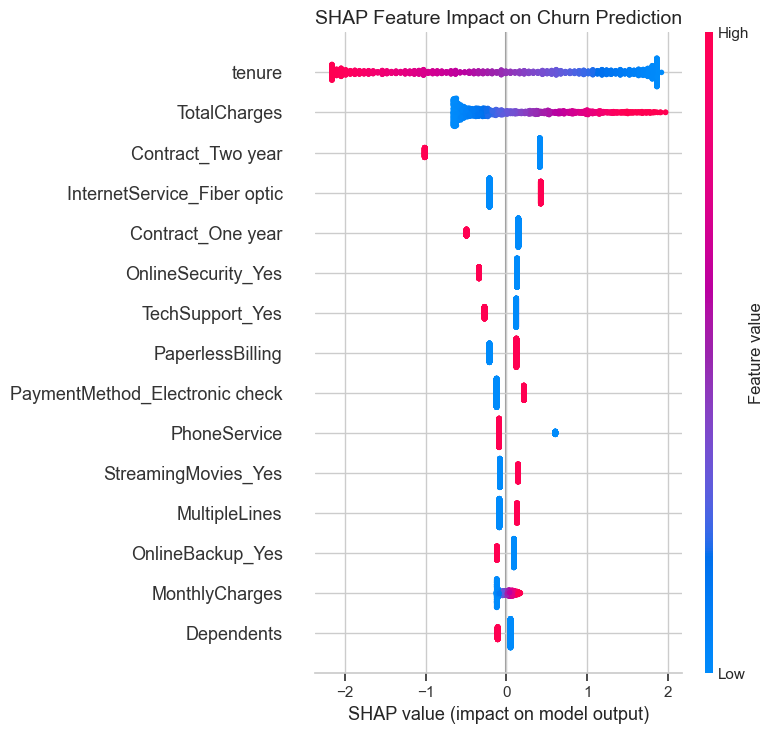

In [20]:
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title("SHAP Feature Impact on Churn Prediction", fontsize=14)
plt.tight_layout()
plt.savefig('../shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

## Single Customer Explanation

Customer #10 Prediction: 🟢 WON'T CHURN
Churn Probability: 19.9%
Actual: No Churn


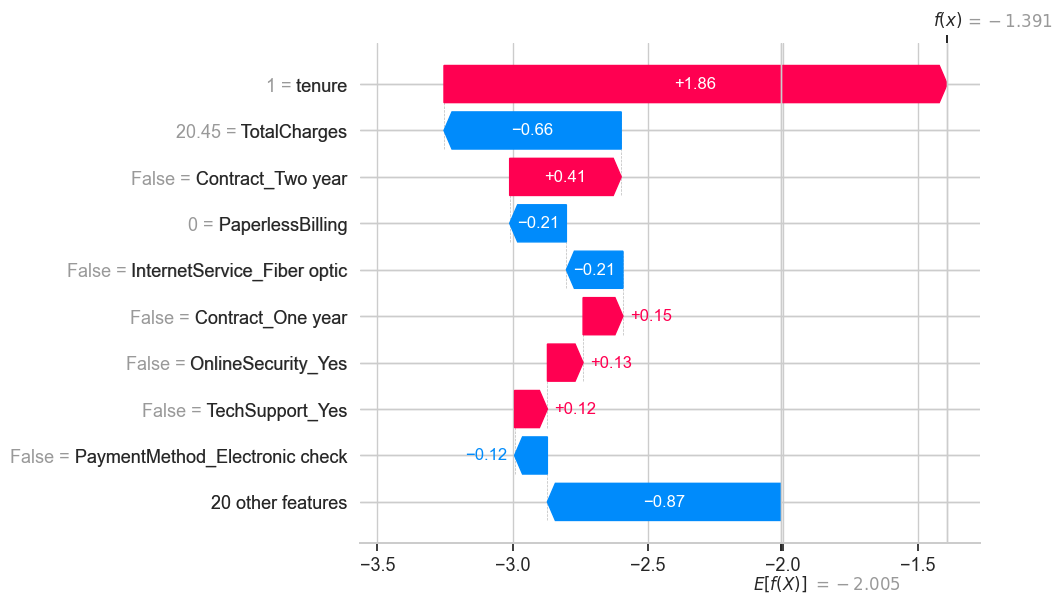

In [21]:
# Explain prediction for 1 customer
sample_idx = 10  # You can change this index

# Get prediction for this customer
sample = X_test.iloc[[sample_idx]]
pred_prob = best_model.predict_proba(sample)[0][1]
pred_label = "🔴 WILL CHURN" if pred_prob > 0.5 else "🟢 WON'T CHURN"

print(f"Customer #{sample_idx} Prediction: {pred_label}")
print(f"Churn Probability: {pred_prob*100:.1f}%")
print(f"Actual: {'Churn' if y_test.iloc[sample_idx] == 1 else 'No Churn'}")

# Waterfall plot - why this prediction?
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=X_test.columns.tolist()
    )
)

## Saving SHAP Explainer

In [22]:
# Save SHAP explainer for use in Streamlit app
with open('../explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("✅ SHAP explainer saved!")

✅ SHAP explainer saved!


## Streamlit App

In [ ]:
#pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import json
import shap
import matplotlib.pyplot as plt

# ─── Page Config ───────────────────────────────────────────
st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="🔮",
    layout="wide"
)

# ─── Load Model & Explainer ────────────────────────────────
@st.cache_resource
def load_artifacts():
    with open('../model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('../explainer.pkl', 'rb') as f:
        explainer = pickle.load(f)
    with open('../model_columns.json', 'r') as f:
        columns = json.load(f)
    return model, explainer, columns

model, explainer, model_columns = load_artifacts()

# ─── Header ────────────────────────────────────────────────
st.title("🔮 Customer Churn Predictor")
st.markdown("### Predict whether a customer will churn — and understand *why*")
st.divider()

# ─── Sidebar Inputs ────────────────────────────────────────
st.sidebar.header("👤 Customer Details")
st.sidebar.markdown("Fill in the customer information below:")

# Personal Info
gender = st.sidebar.selectbox("Gender", ["Male", "Female"])
senior = st.sidebar.selectbox("Senior Citizen", ["No", "Yes"])
partner = st.sidebar.selectbox("Has Partner", ["Yes", "No"])
dependents = st.sidebar.selectbox("Has Dependents", ["Yes", "No"])
tenure = st.sidebar.slider("Tenure (months)", 0, 72, 12)

# Services
st.sidebar.markdown("---")
st.sidebar.markdown("**📡 Services**")
phone_service = st.sidebar.selectbox("Phone Service", ["Yes", "No"])
multiple_lines = st.sidebar.selectbox("Multiple Lines", ["Yes", "No"])
internet_service = st.sidebar.selectbox("Internet Service", 
                    ["DSL", "Fiber optic", "No"])
online_security = st.sidebar.selectbox("Online Security", ["Yes", "No"])
online_backup = st.sidebar.selectbox("Online Backup", ["Yes", "No"])
device_protection = st.sidebar.selectbox("Device Protection", ["Yes", "No"])
tech_support = st.sidebar.selectbox("Tech Support", ["Yes", "No"])
streaming_tv = st.sidebar.selectbox("Streaming TV", ["Yes", "No"])
streaming_movies = st.sidebar.selectbox("Streaming Movies", ["Yes", "No"])

# Billing
st.sidebar.markdown("---")
st.sidebar.markdown("**💳 Billing**")
contract = st.sidebar.selectbox("Contract Type", 
            ["Month-to-month", "One year", "Two year"])
paperless = st.sidebar.selectbox("Paperless Billing", ["Yes", "No"])
payment = st.sidebar.selectbox("Payment Method", 
            ["Electronic check", "Mailed check",
             "Bank transfer (automatic)", "Credit card (automatic)"])
monthly_charges = st.sidebar.slider("Monthly Charges ($)", 0.0, 120.0, 65.0)
total_charges = st.sidebar.slider("Total Charges ($)", 
                0.0, 9000.0, float(tenure * monthly_charges))

# ─── Preprocess Input ──────────────────────────────────────
def preprocess_input():
    data = {
        'gender': 1 if gender == 'Male' else 0,
        'SeniorCitizen': 1 if senior == 'Yes' else 0,
        'Partner': 1 if partner == 'Yes' else 0,
        'Dependents': 1 if dependents == 'Yes' else 0,
        'tenure': tenure,
        'PhoneService': 1 if phone_service == 'Yes' else 0,
        'MultipleLines': 1 if multiple_lines == 'Yes' else 0,
        'PaperlessBilling': 1 if paperless == 'Yes' else 0,
        'MonthlyCharges': monthly_charges,
        'TotalCharges': total_charges,
        'InternetService_Fiber optic': 1 if internet_service == 'Fiber optic' else 0,
        'InternetService_No': 1 if internet_service == 'No' else 0,
        'OnlineSecurity_Yes': 1 if online_security == 'Yes' else 0,
        'OnlineBackup_Yes': 1 if online_backup == 'Yes' else 0,
        'DeviceProtection_Yes': 1 if device_protection == 'Yes' else 0,
        'TechSupport_Yes': 1 if tech_support == 'Yes' else 0,
        'StreamingTV_Yes': 1 if streaming_tv == 'Yes' else 0,
        'StreamingMovies_Yes': 1 if streaming_movies == 'Yes' else 0,
        'Contract_One year': 1 if contract == 'One year' else 0,
        'Contract_Two year': 1 if contract == 'Two year' else 0,
        'PaymentMethod_Credit card (automatic)': 1 if payment == 'Credit card (automatic)' else 0,
        'PaymentMethod_Electronic check': 1 if payment == 'Electronic check' else 0,
        'PaymentMethod_Mailed check': 1 if payment == 'Mailed check' else 0,
    }
    df = pd.DataFrame([data])

    # Align with model columns
    for col in model_columns:
        if col not in df.columns:
            df[col] = 0
    df = df[model_columns]
    return df

# ─── Predict Button ────────────────────────────────────────
col1, col2, col3 = st.columns([1, 2, 1])
with col2:
    predict_btn = st.button("🔮 Predict Churn", 
                             use_container_width=True,
                             type="primary")

st.divider()

# ─── Results ───────────────────────────────────────────────
if predict_btn:
    input_df = preprocess_input()
    pred_prob = model.predict_proba(input_df)[0][1]
    pred_label = 1 if pred_prob > 0.5 else 0

    # Result columns
    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown("### 🎯 Prediction")
        if pred_label == 1:
            st.error("🔴 WILL CHURN")
        else:
            st.success("🟢 WON'T CHURN")

    with col2:
        st.markdown("### 📊 Churn Probability")
        st.metric(label="Probability", 
                  value=f"{pred_prob*100:.1f}%")
        st.progress(float(pred_prob))

    with col3:
        st.markdown("### ⚠️ Risk Level")
        if pred_prob < 0.3:
            st.success("🟢 LOW RISK")
        elif pred_prob < 0.6:
            st.warning("🟡 MEDIUM RISK")
        else:
            st.error("🔴 HIGH RISK")

    st.divider()

    # SHAP Explanation
    st.markdown("### 🔍 Why this prediction? (SHAP Explanation)")
    shap_vals = explainer.shap_values(input_df)

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_vals[0],
            base_values=explainer.expected_value,
            data=input_df.iloc[0],
            feature_names=model_columns
        ),
        show=False
    )
    st.pyplot(fig)
    plt.close()

    st.divider()

    # Top Risk Factors
    st.markdown("### 🚨 Top Risk Factors")
    shap_df = pd.DataFrame({
        'Feature': model_columns,
        'SHAP Value': shap_vals[0]
    }).sort_values('SHAP Value', ascending=False)

    top_risk = shap_df[shap_df['SHAP Value'] > 0].head(5)
    top_protect = shap_df[shap_df['SHAP Value'] < 0].head(5)

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**🔴 Factors Increasing Churn Risk:**")
        for _, row in top_risk.iterrows():
            st.markdown(f"- `{row['Feature']}` → +{row['SHAP Value']:.3f}")

    with col2:
        st.markdown("**🟢 Factors Reducing Churn Risk:**")
        for _, row in top_protect.iterrows():
            st.markdown(f"- `{row['Feature']}` → {row['SHAP Value']:.3f}")

2026-03-22 19:53:24.475 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 19:53:24.475 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 19:53:25.919 
  command:

    streamlit run C:\Users\ritik\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-22 19:53:25.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 19:53:25.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 19:53:25.929 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 19:53:26.009 Thread 'MainThread': missing ScriptRunContext! This warning can b